# ATM 407: can convection keep up?

You are the scientist responsible for one atmospheric column inside a global model. The dynamical core will try to lift and destabilize that column; the physics packages will try to restore a balanced state. Your job is to predict which process wins, implement the dynamical forcing, and defend your interpretation with diagnostics.

### Learning goals

By the end of the lab you should be able to:

1. connect hydrostatic balance to atmospheric mass on a sigma grid;
2. diagnose static stability using potential temperature and $N^2$;
3. distinguish resolved dynamical forcing from parameterized physics tendencies;
4. implement vertical advection and adiabatic temperature change in pressure coordinates; and
5. explain how forcing and convective-adjustment timescales control CAPE and rainfall.

The SCM has no horizontal pressure-gradient force, Coriolis acceleration, or internally resolved circulation. Here, large-scale vertical motion is supplied externally, exactly as an observationally forced SCM or a host dynamical core would supply it.

**Lab rule:** make a written prediction before every experiment. A wrong forecast with a good physical explanation is more valuable than a correct guess made afterward.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evanwellmeyer/GCM/blob/main/notebooks/02_experiments_atm407.ipynb)

## Colab setup

Run this cell first. It installs the current model and verifies that Python can import it.

In [1]:
#@title Install and connect the SCM { display-mode: "form" }
from pathlib import Path
import json
import subprocess
import sys

incolab = 'google.colab' in sys.modules
if incolab:
    root = Path('/content/GCM')
    if not root.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1',
            'https://github.com/evanwellmeyer/GCM.git', str(root),
        ], check=True)
else:
    root = Path.cwd().resolve()
    while root != root.parent and not (root / 'pyproject.toml').exists():
        root = root.parent

if not (root / 'pyproject.toml').exists():
    raise FileNotFoundError('Open this notebook from inside the GCM repository.')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from importlib import metadata, util

try:
    metadata.version('gcm-scm')
    installed = util.find_spec('matplotlib') is not None
except metadata.PackageNotFoundError:
    installed = False

if not installed:
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '--quiet', '-e', f'{root}[plot]',
    ], check=True)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import scm
print('SCM ready')

SCM ready


In [2]:
#@title Imports and visual style { display-mode: "form" }
from copy import deepcopy
import time

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import numpy as np
import torch

from scm.column_model import initial_state, physics_step, run, update_derived
from scm.configuration import extract_param_overrides, load_run_config
from scm.ensemble import default_params
from scm.thermo import Rd, cp, g, geopotential, make_grid, relative_humidity

torch.manual_seed(0)
device = torch.device('cpu')
plt.rcParams.update({
    'figure.facecolor': '#f7f3ea',
    'axes.facecolor': '#fffdf7',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 11,
})
colors = {
    'sky': '#3a86ff', 'storm': '#264653', 'rain': '#00a896',
    'heat': '#ef476f', 'sun': '#ffb703', 'cloud': '#8d99ae',
}
print('device:', device)

device: cpu


## Meet your atmospheric column

We begin from a saved, nearly steady radiative-convective column rather than spending class time on a long spin-up. Radiation, surface fluxes, and convection are already active, so this is a moving balance--not a motionless atmosphere.

The reference has small energy imbalances, moderate CAPE, precipitation dominated by deep convection, and no active numerical limiters. It is an idealized laboratory atmosphere, not an observed climatological sounding. Think of it as the control member against which every forecast will be judged.

The saved equilibrium has 20 native levels, so the main lab keeps that scientifically consistent grid. A smoother-looking 40-level interpolation is not automatically a better atmosphere: remapping can alter stability and disturb the balance. You can investigate that distinction in the optional boss level.

The code cell below contains plumbing used throughout the lab. You do not need to memorize it. The governing equations that you are responsible for will be derived and implemented later in the lesson.

In [3]:
#@title Lab helper functions { display-mode: "form" }
experiment = {
    'nlevels': 20,
    'dt': 900.0,
    'days': 3,
    'diagnostic_hours': 3,
    'radiation_steps': 8,
    'surface_temperature': 290.0,
    'surface_pressure': 100000.0,
    'solar_constant': 1360.0,
    'zenith_factor': 0.25,
    'ocean_depth': 50.0,
    'surface_albedo': 0.32,
    'wind_speed': 5.0,
}

referencemetadata = json.loads(
    (root / 'notebooks/data/atm407_equilibrium_20level.json').read_text()
)
print('reference configuration:', referencemetadata['configuration_label'])
print(f"reference surface temperature: {referencemetadata['surface_temperature_k']:.2f} K")
print(f"saved 20-level CAPE: {referencemetadata['cape_jkg']:.0f} J kg-1")
print(f"saved 20-level precipitation: {referencemetadata['precipitation_mmday']:.2f} mm day-1")
print(f"mass at or above 95% RH: {referencemetadata['rh95_mass_fraction']:.0%}")
print(f"mass-flux cap-active fraction: {referencemetadata['mass_flux_cap_fraction']:.0%}")

def makeparams(settings, updates=None):
    params = default_params(device=device)
    params.update(extract_param_overrides(load_run_config()))
    params.update({
        'dt': settings['dt'],
        'ps0': settings['surface_pressure'],
        'ts_init': settings['surface_temperature'],
        'solar_constant': settings['solar_constant'],
        'zenith_factor': settings['zenith_factor'],
        'ocean_depth': settings['ocean_depth'],
        'albedo': settings['surface_albedo'],
        'wind_speed': settings['wind_speed'],
        'convection_scheme': 'mass_flux',
        'radiation_scheme': 'multiband',
        'use_slab_ocean': True,
        'profile_diagnostics': True,
    })
    if updates is not None:
        params.update(updates)
    return params

def loadreference(nlevels=20, batch=1):
    reference = np.load(root / 'notebooks/data/atm407_equilibrium_20level.npz')
    settings = dict(experiment)
    settings['nlevels'] = nlevels
    grid = make_grid(nlevels, device=device)
    params = makeparams(settings)
    state = initial_state(batch, grid, params, device=device)
    sourcesigma = reference['sigma_full']
    targetsigma = grid['sigma_full'].cpu().numpy()

    for name in ['t', 'q', 'qc', 'cloud_fraction']:
        profile = np.interp(targetsigma, sourcesigma, reference[name])
        values = torch.as_tensor(profile, dtype=state[name].dtype, device=device)
        state[name] = values.unsqueeze(0).repeat(batch, 1)

    referencegrid = make_grid(len(sourcesigma), device=device)
    sourcedsigma = referencegrid['dsigma'].cpu().numpy()
    sourcewater = np.sum(reference['q'] * sourcedsigma)
    targetwater = torch.sum(state['q'][0] * grid['dsigma']).item()
    state['q'] = state['q'] * (sourcewater / targetwater)
    state['ts'].fill_(float(reference['ts']))
    state['ps'].fill_(float(reference['ps']))
    state['slab_ts_ref'] = state['ts'].clone()
    state['slab_energy'].zero_()
    return update_derived(state, grid)

def integrate(settings, updates=None, batch=1, state=None, lsforcing=None):
    grid = make_grid(settings['nlevels'], device=device)
    params = makeparams(settings, updates)
    if state is None:
        state = initial_state(batch, grid, params, device=device)
    stepsperday = round(86400 / settings['dt'])
    nsteps = round(settings['days'] * stepsperday)
    diagnosticsteps = max(1, round(settings['diagnostic_hours'] * 3600 / settings['dt']))
    start = time.perf_counter()
    state, history = run(
        state, grid, params, nsteps,
        rad_interval=settings['radiation_steps'],
        diag_interval=diagnosticsteps,
        ls_forcing=lsforcing,
    )
    elapsed = time.perf_counter() - start
    return grid, params, state, history, elapsed

def series(history, name, member=0, scale=1.0):
    values = [entry[name][member].detach().cpu().item() for entry in history]
    return np.array(values) * scale

def days(history, dt):
    return np.array([entry['step'] for entry in history]) * dt / 86400

reference configuration: mf_response_v3
reference surface temperature: 284.44 K
saved 20-level CAPE: 1434 J kg-1
saved 20-level precipitation: 1.92 mm day-1
mass at or above 95% RH: 4%
mass-flux cap-active fraction: 0%


## Mission 1: weigh the atmosphere without a scale

Hydrostatic balance says $dp=-\rho g\,dz$. Integrating through one layer and dividing by area gives

$$m_{layer}/A=\frac{\Delta p}{g}.$$

That is why a pressure thickness is also a mass coordinate. This model uses $\sigma=p/p_s$, so its levels move with surface pressure while retaining a fixed fractional position in the column.

**Forecast before plotting:** Are the layers equally spaced in pressure? Which portion of the atmosphere contains the most mass?

> **Your prediction:** Write one or two sentences here before running the cell.

Run the calculation, verify that $\sum\Delta p/g=p_s/g$, and explain why this identity is a useful conservation check for a dynamical core.

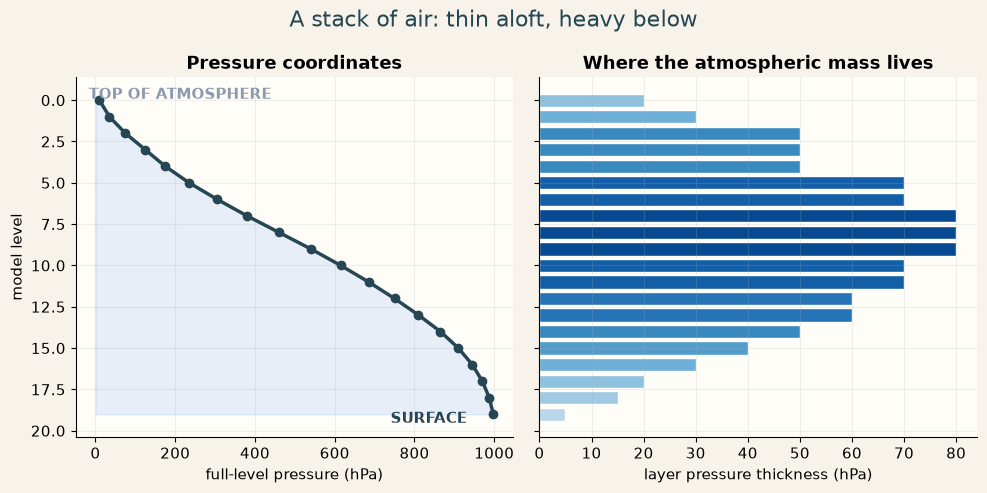

layer sum: 10193.68 kg m-2
ps / g:    10193.68 kg m-2


In [4]:
grid = make_grid(experiment['nlevels'], device=device)
params = makeparams(experiment)
state = loadreference(experiment['nlevels'])
pressure = state['p'][0].cpu().numpy() / 100
deltap = state['dp'][0].cpu().numpy() / 100
levels = np.arange(experiment['nlevels'])
layercolors = plt.cm.Blues(0.25 + 0.65 * deltap / deltap.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes[0].plot(pressure, levels, marker='o', color=colors['storm'], linewidth=2.5)
axes[0].fill_betweenx(levels, 0, pressure, color=colors['sky'], alpha=0.12)
axes[0].set(xlabel='full-level pressure (hPa)', ylabel='model level', title='Pressure coordinates')
axes[1].barh(levels, deltap, color=layercolors, edgecolor='white')
axes[1].set(xlabel='layer pressure thickness (hPa)', title='Where the atmospheric mass lives')
axes[0].invert_yaxis()
for ax in axes:
    ax.grid(alpha=0.2)
axes[0].text(0.03, 0.94, 'TOP OF ATMOSPHERE', transform=axes[0].transAxes,
             color=colors['cloud'], fontweight='bold')
axes[0].text(0.72, 0.04, 'SURFACE', transform=axes[0].transAxes,
             color=colors['storm'], fontweight='bold')
fig.suptitle('A stack of air: thin aloft, heavy below', fontsize=16, color=colors['storm'])
fig.tight_layout()
plt.show()

massfromlayers = state['dp'].sum().item() / g
massfromsurface = state['ps'].item() / g
print(f'layer sum: {massfromlayers:.2f} kg m-2')
print(f'ps / g:    {massfromsurface:.2f} kg m-2')

## Mission 2: find the atmosphere's weak spots

A rising dry parcel cools by expansion, so temperature alone does not tell us whether it will return to its starting level. Potential temperature removes that adiabatic pressure effect:

$$\theta=T\left(\frac{p_0}{p}\right)^{R_d/c_p}.$$

The dry Brunt--Vaisala frequency measures the restoring force:

$$N^2=\frac{g}{\theta}\frac{\partial\theta}{\partial z}.$$

If $N^2>0$, a displaced parcel oscillates; if $N^2<0$, dry overturning is favored. Small $N^2$ marks a layer that is easy to disturb.

**Forecast before plotting:** Where do you expect the strongest stability: boundary layer, free troposphere, or stratosphere?

> **Your prediction:** Record the layer and your physical reason.

Use the four panels to identify stable and unstable layers. A few negative values near the surface are not automatically a model failure: this is a discretized, turbulent boundary layer, while $N^2$ here is a dry parcel diagnostic. Treat them as a clue to discuss what the boundary-layer physics must continually mix. Then quantify the atmospheric mass at or above 95% RH and explain why this idealized column is not an observed tropical mean sounding.


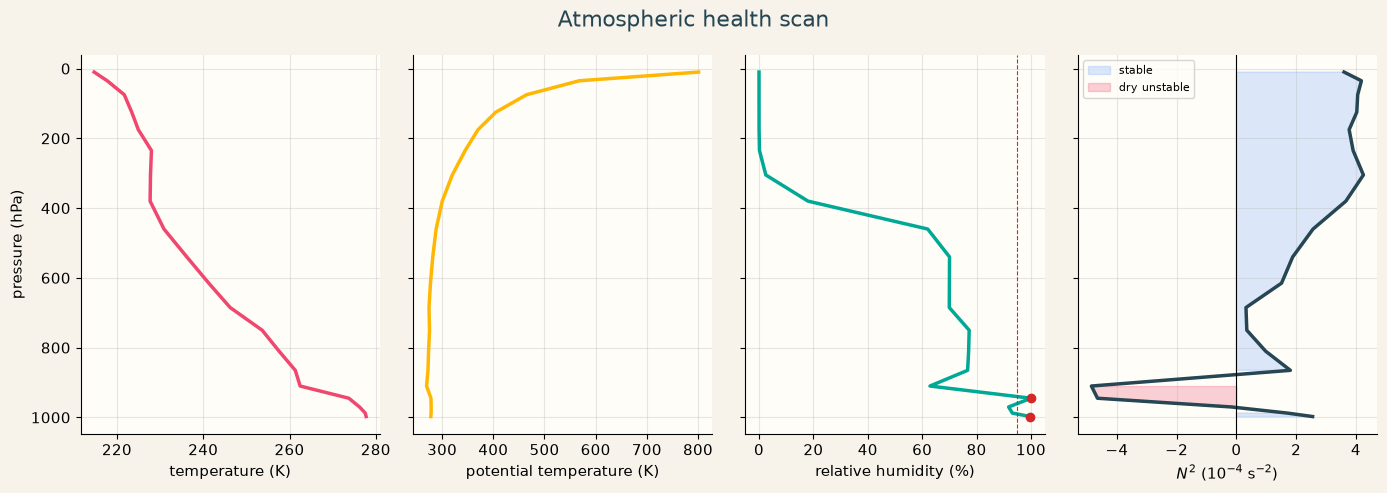

mass at or above 95% RH: 4%
height range: 0.0 to 30.4 km
minimum dry N2: -4.85e-04 s-2
levels with dry N2 below zero (hPa): [910. 945. 970.]


In [5]:
temperature = state['t'][0]
pressurepa = state['p'][0]
theta = temperature * (100000.0 / pressurepa) ** (Rd / cp)
rh = relative_humidity(state['q'], state['t'], state['p'])[0] * 100
height = geopotential(state['t'], state['q'], state['p'], grid)[0]
dthetadz = np.gradient(theta.cpu().numpy(), height.cpu().numpy())
n2 = g / theta.cpu().numpy() * dthetadz

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
axes[0].plot(temperature.cpu(), pressure, color=colors['heat'], linewidth=2.5)
axes[0].set_xlabel('temperature (K)')
axes[1].plot(theta.cpu(), pressure, color=colors['sun'], linewidth=2.5)
axes[1].set_xlabel('potential temperature (K)')
axes[2].plot(rh.cpu(), pressure, color=colors['rain'], linewidth=2.5)
axes[2].plot(rh[rh >= 95].cpu(), pressure[rh.cpu().numpy() >= 95], 'o', color='tab:red')
axes[2].axvline(95, color='tab:red', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('relative humidity (%)')
axes[3].plot(n2 * 1e4, pressure, color=colors['storm'], linewidth=2.5)
axes[3].fill_betweenx(pressure, 0, n2 * 1e4, where=n2 >= 0, color=colors['sky'], alpha=0.18, label='stable')
axes[3].fill_betweenx(pressure, 0, n2 * 1e4, where=n2 < 0, color=colors['heat'], alpha=0.25, label='dry unstable')
axes[3].axvline(0, color='black', linewidth=0.8)
axes[3].legend(fontsize=8, loc='upper left')
axes[3].set_xlabel(r'$N^2$ ($10^{-4}$ s$^{-2}$)')
axes[0].set_ylabel('pressure (hPa)')
axes[0].invert_yaxis()
for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle('Atmospheric health scan', fontsize=16, color=colors['storm'])
fig.tight_layout()
plt.show()
saturatedmass = state['dp'][0, rh >= 95].sum() / state['dp'][0].sum()
print(f'mass at or above 95% RH: {saturatedmass.item():.0%}')
print(f'height range: {height.min().item() / 1000:.1f} to {height.max().item() / 1000:.1f} km')
print(f'minimum dry N2: {n2.min():+.2e} s-2')
print('levels with dry N2 below zero (hPa):', np.round(pressure[n2 < 0], 1))

## Mission 3: become a tendency detective

A GCM usually separates its work into two pieces:

- the **dynamical core** transports mass, momentum, heat, and water;
- the **physics column** represents radiation, surface exchange, turbulence, convection, condensation, and clouds.

Radiation and surface exchange can change the column's total moist energy because they cross its boundaries. Mixing and convection mostly rearrange heat and water internally, so a column integral can hide large opposing tendencies at individual levels.

**Forecast before plotting:** Which process should cool the upper atmosphere? Which should warm and moisten the lowest levels? Which should transport heat upward?

> **Your prediction:** Assign at least three processes to an expected sign and layer.

After running the cell, choose one surprising tendency and explain its sign in physical terms.

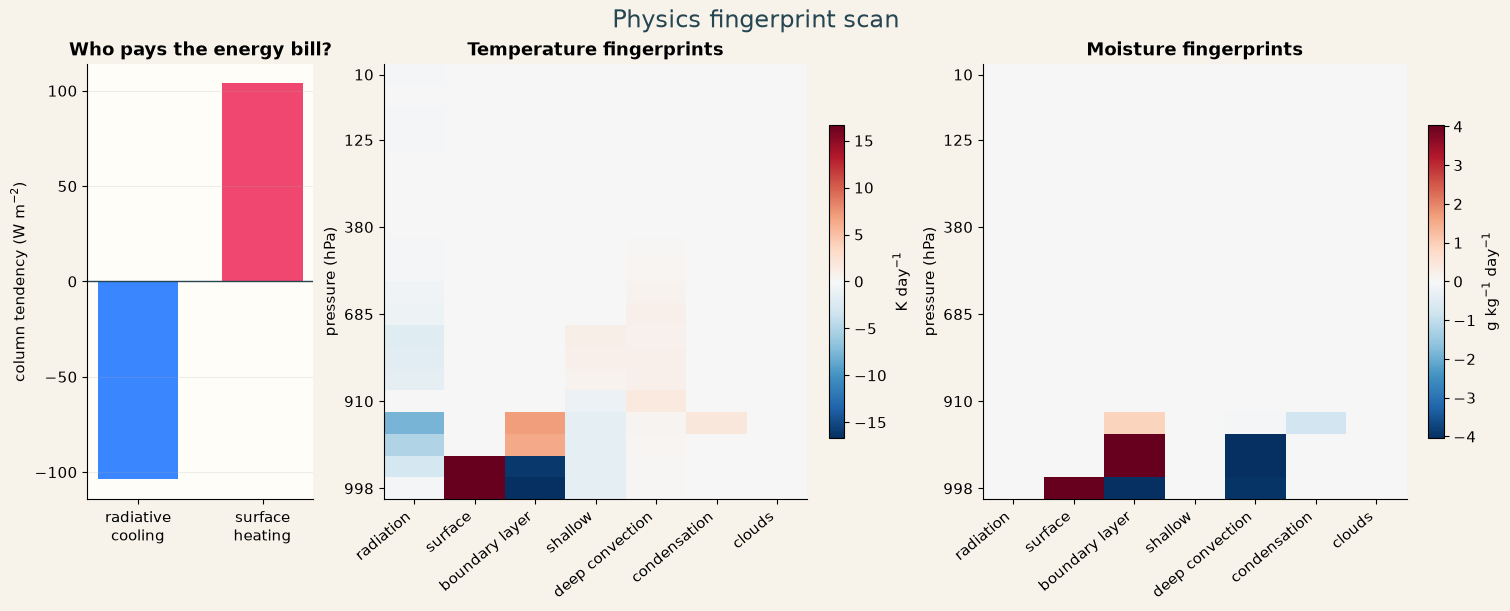

TOA net flux: +0.55 W m-2
surface total flux: -0.15 W m-2
column residual: +0.08 W m-2


In [6]:
#@title Reveal the physics tendency fingerprints { display-mode: "form" }
stepstate = deepcopy(state)
stepstate, diagnostics, radiationcache = physics_step(stepstate, grid, params)
processes = [
    ('radiation', 'radiation'), ('surface', 'surface'),
    ('boundary layer', 'boundary_layer'), ('shallow', 'shallow'),
    ('deep convection', 'deep'), ('condensation', 'condensation'),
    ('clouds', 'cloud'),
]
names = [label for label, key in processes]
temperaturemap = np.array([
    diagnostics[f'{key}_temperature_tendency'][0].cpu() * 86400
    for label, key in processes
])
moisturemap = np.array([
    diagnostics[f'{key}_moisture_tendency'][0].cpu() * 86400 * 1000
    for label, key in processes
])
boundaryvalues = np.array([
    diagnostics['rad_energy_tendency'][0].item(),
    diagnostics['surface_energy_tendency'][0].item(),
])

fig = plt.figure(figsize=(15, 6), constrained_layout=True)
layout = fig.add_gridspec(1, 3, width_ratios=[0.8, 1.5, 1.5])
axes = [fig.add_subplot(layout[0, index]) for index in range(3)]

barcolors = [colors['heat'] if value > 0 else colors['sky'] for value in boundaryvalues]
axes[0].bar(['radiative\ncooling', 'surface\nheating'], boundaryvalues, color=barcolors, width=0.65)
axes[0].axhline(0, color=colors['storm'], linewidth=1)
axes[0].set(title='Who pays the energy bill?', ylabel='column tendency (W m$^{-2}$)')
axes[0].grid(axis='y', alpha=0.2)

for ax, values, title, label in [
    (axes[1], temperaturemap, 'Temperature fingerprints', 'K day$^{-1}$'),
    (axes[2], moisturemap, 'Moisture fingerprints', 'g kg$^{-1}$ day$^{-1}$'),
]:
    limit = max(np.nanpercentile(np.abs(values), 98), 1e-6)
    image = ax.imshow(values.T, origin='upper', aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
    ticklevels = np.linspace(0, len(pressure) - 1, 6).astype(int)
    ax.set_xticks(range(len(names)), names, rotation=40, ha='right')
    ax.set_yticks(ticklevels, [f'{pressure[index]:.0f}' for index in ticklevels])
    ax.set(title=title, ylabel='pressure (hPa)')
    fig.colorbar(image, ax=ax, shrink=0.72, label=label)

fig.suptitle('Physics fingerprint scan', fontsize=17, color=colors['storm'])
plt.show()
print(f"TOA net flux: {diagnostics['toa_net'][0].item():+.2f} W m-2")
print(f"surface total flux: {diagnostics['surface_total_flux'][0].item():+.2f} W m-2")
print(f"column residual: {diagnostics['column_energy_residual'][0].item():+.2f} W m-2")

## Mission 4: build the dynamical forcing

Now you will write the bridge between dynamics and physics. In pressure coordinates, $\omega=Dp/Dt$ is negative for ascent. Ignoring horizontal advection,

$$\frac{\partial T}{\partial t}=\underbrace{-\omega\frac{\partial T}{\partial p}}_{\text{vertical advection}}+\underbrace{\frac{R_d}{c_p}\frac{T\omega}{p}}_{\text{adiabatic expansion}},$$

$$\frac{\partial q}{\partial t}=-\omega\frac{\partial q}{\partial p}.$$

The first temperature term moves the environmental profile through the column. The second is compressional heating or expansional cooling. Their sum determines the local temperature response.

We prescribe $\omega(p)$ to be zero at the top and surface and strongest near $\sigma=0.5$. It acts for one day; the column then adjusts freely for two days.

**Forecast before coding:** For ascent, predict the signs of vertical temperature advection, adiabatic expansion, total temperature tendency, and moisture tendency. Will CAPE and deep rain increase or decrease?

> **Your prediction:** Make a sign table and forecast the CAPE/rain response.

After the static diagnosis, press play on the animated storm dashboard. The blue shading marks the day when large-scale ascent is switched on.

In [7]:
# First implement the pressure derivatives used in the equations above.
def pressuregradient(field, pressure):
    gradient = torch.zeros_like(field)
    gradient[:, 1:-1] = (field[:, 2:] - field[:, :-2]) / (pressure[:, 2:] - pressure[:, :-2])
    gradient[:, 0] = (field[:, 1] - field[:, 0]) / (pressure[:, 1] - pressure[:, 0])
    gradient[:, -1] = (field[:, -1] - field[:, -2]) / (pressure[:, -1] - pressure[:, -2])
    return gradient

# This function recomputes the forcing from the evolving model state.
def ascentforcing(grid, peakomega, durationdays=1.0):
    peakomega = torch.as_tensor(peakomega, dtype=torch.float32, device=device).reshape(-1, 1)
    durationdays = torch.as_tensor(durationdays, dtype=torch.float32, device=device).reshape(-1, 1)
    sigma = grid['sigma_full'].to(device=device, dtype=torch.float32).reshape(1, -1)
    shape = torch.sin(torch.pi * sigma).clamp(min=0.0)

    def forcing(step, state):
        active = step * experiment['dt'] < durationdays * 86400
        if not torch.any(active):
            return None
        pressure = state['p']
        omega = -peakomega.to(pressure.dtype) * shape.to(pressure.dtype)
        omega = omega * active.to(pressure.dtype)
        dtdp = pressuregradient(state['t'], pressure)
        dqdp = pressuregradient(state['q'], pressure)

        verticaladvection = -omega * dtdp
        adiabaticexpansion = (Rd / cp) * state['t'] * omega / pressure
        temperaturetendency = verticaladvection + adiabaticexpansion
        moisturetendency = -omega * dqdp
        return {
            'dt': temperaturetendency,
            'dq': moisturetendency,
            'verticaladvection': verticaladvection,
            'adiabaticexpansion': adiabaticexpansion,
        }

    return forcing

grid = make_grid(experiment['nlevels'], device=device)
peakomega = 0.05
forcing = ascentforcing(grid, [peakomega], durationdays=1.0)

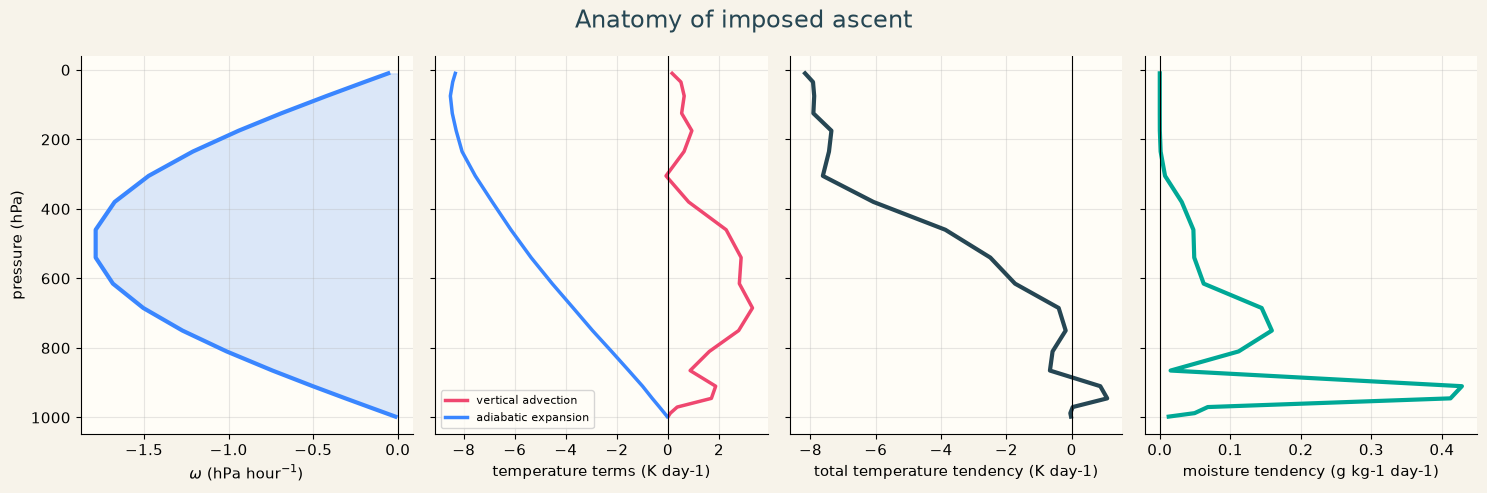

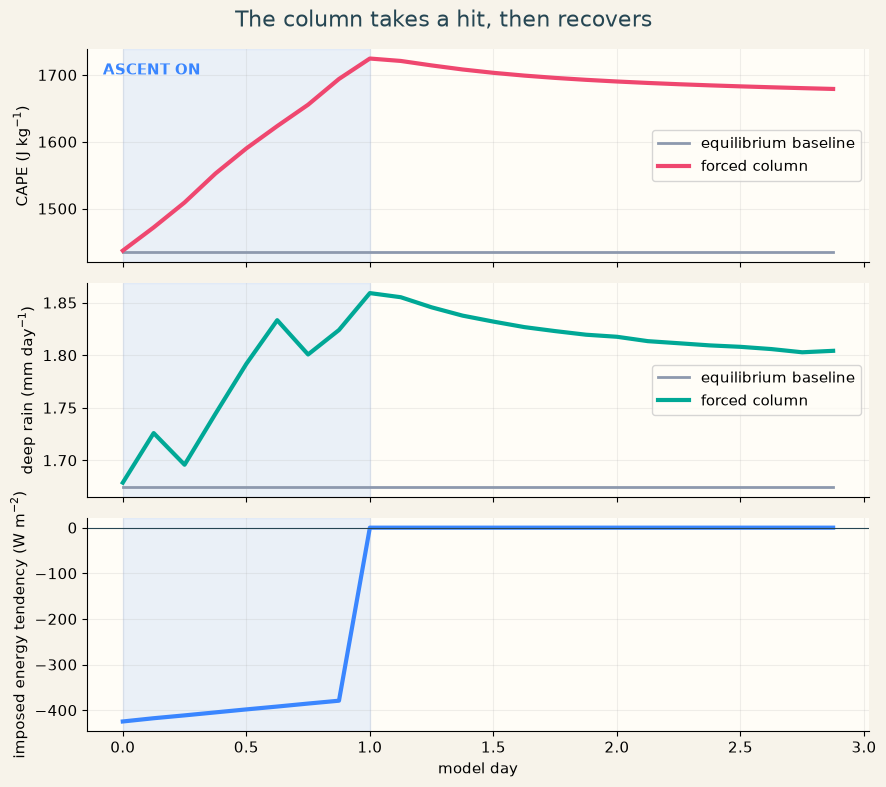

maximum ascent: -1.80 hPa hour-1
equilibrium deep rain: 1.67 mm day-1
forced mean deep rain: 1.80 mm day-1
forced-run runtime: 7.1 s


In [8]:
#@title Run and reveal the ascent experiment { display-mode: "form" }
previewstate = loadreference(experiment['nlevels'])
preview = forcing(0, previewstate)
baselinestate, baselinediagnostics, baselinecache = physics_step(
    deepcopy(previewstate), grid, params
)
baselinecape = baselinediagnostics['cape'][0].item()
baselinerain = baselinediagnostics['precip_conv'][0].item() * 86400
omega = -peakomega * np.sin(np.pi * grid['sigma_full'].cpu().numpy())

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
axes[0].plot(omega * 36, pressure, color=colors['sky'], linewidth=3)
axes[0].fill_betweenx(pressure, omega * 36, 0, color=colors['sky'], alpha=0.18)
axes[0].set(xlabel=r'$\omega$ (hPa hour$^{-1}$)', ylabel='pressure (hPa)')
axes[1].plot(preview['verticaladvection'][0].cpu() * 86400, pressure, color=colors['heat'], linewidth=2.5, label='vertical advection')
axes[1].plot(preview['adiabaticexpansion'][0].cpu() * 86400, pressure, color=colors['sky'], linewidth=2.5, label='adiabatic expansion')
axes[1].set_xlabel('temperature terms (K day-1)')
axes[1].legend(fontsize=8)
axes[2].plot(preview['dt'][0].cpu() * 86400, pressure, color=colors['storm'], linewidth=3)
axes[2].set_xlabel('total temperature tendency (K day-1)')
axes[3].plot(preview['dq'][0].cpu() * 86400 * 1000, pressure, color=colors['rain'], linewidth=3)
axes[3].set_xlabel('moisture tendency (g kg-1 day-1)')
for ax in axes:
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(alpha=0.3)
axes[0].invert_yaxis()
fig.suptitle('Anatomy of imposed ascent', fontsize=17, color=colors['storm'])
fig.tight_layout()
plt.show()

forcedstate = loadreference(experiment['nlevels'])
grid, params, forcedstate, forcedhistory, forcedelapsed = integrate(
    experiment, state=forcedstate, lsforcing=forcing
)
timeaxis = days(forcedhistory, experiment['dt'])
forcedcape = series(forcedhistory, 'cape')
forcedrain = series(forcedhistory, 'precip_conv', scale=86400)
controlcape = np.full_like(forcedcape, baselinecape)
controlrain = np.full_like(forcedrain, baselinerain)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(timeaxis, controlcape, color=colors['cloud'], linewidth=2, label='equilibrium baseline')
axes[0].plot(timeaxis, forcedcape, color=colors['heat'], linewidth=3, label='forced column')
axes[0].set_ylabel('CAPE (J kg$^{-1}$)')
axes[0].legend()
axes[1].plot(timeaxis, controlrain, color=colors['cloud'], linewidth=2, label='equilibrium baseline')
axes[1].plot(timeaxis, forcedrain, color=colors['rain'], linewidth=3, label='forced column')
axes[1].set_ylabel('deep rain (mm day$^{-1}$)')
axes[1].legend()
axes[2].plot(timeaxis, series(forcedhistory, 'forcing_energy_tendency'),
             color=colors['sky'], linewidth=3)
axes[2].axhline(0, color=colors['storm'], linewidth=0.8)
axes[2].set(xlabel='model day', ylabel='imposed energy tendency (W m$^{-2}$)')
for ax in axes:
    ax.axvspan(0, 1, color=colors['sky'], alpha=0.10)
    ax.grid(alpha=0.2)
axes[0].text(0.02, 0.88, 'ASCENT ON', transform=axes[0].transAxes,
             color=colors['sky'], fontweight='bold')
fig.suptitle('The column takes a hit, then recovers', fontsize=16, color=colors['storm'])
fig.tight_layout()
plt.show()
print(f'maximum ascent: {-peakomega * 36:.2f} hPa hour-1')
print(f"equilibrium deep rain: {controlrain[0]:.2f} mm day-1")
print(f"forced mean deep rain: {forcedrain.mean():.2f} mm day-1")
print(f'forced-run runtime: {forcedelapsed:.1f} s')

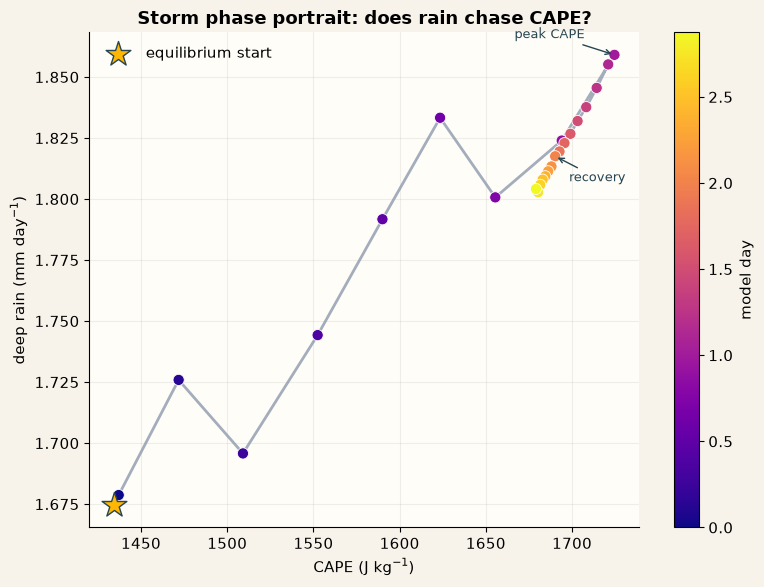

In [9]:
#@title Play the column response { display-mode: "form" }
# GitHub may suppress JavaScript, so this phase portrait is the static summary.
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(forcedcape, forcedrain, color=colors['cloud'], linewidth=2, alpha=0.8)
points = ax.scatter(forcedcape, forcedrain, c=timeaxis, cmap='plasma', s=65,
                    edgecolor='white', linewidth=0.6, zorder=3)
ax.scatter(baselinecape, baselinerain, marker='*', s=350, color=colors['sun'],
           edgecolor=colors['storm'], label='equilibrium start', zorder=4)
peakindex = int(np.argmax(forcedcape))
lateindex = int(np.argmin(np.abs(timeaxis - 2.0)))
for index, label, offset in [
    (peakindex, 'peak CAPE', (-72, 12)),
    (lateindex, 'recovery', (10, -18)),
]:
    ax.annotate(label, (forcedcape[index], forcedrain[index]), xytext=offset,
                textcoords='offset points', fontsize=9, color=colors['storm'],
                arrowprops={'arrowstyle': '->', 'color': colors['storm']})
ax.set(xlabel='CAPE (J kg$^{-1}$)', ylabel='deep rain (mm day$^{-1}$)',
       title='Storm phase portrait: does rain chase CAPE?')
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.colorbar(points, ax=ax, label='model day')
fig.tight_layout()
plt.show()

frames = np.unique(np.linspace(0, len(timeaxis) - 1, min(30, len(timeaxis))).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
capelines = [
    axes[0].plot([], [], color=colors['cloud'], linewidth=2.5, label='control')[0],
    axes[0].plot([], [], color=colors['heat'], linewidth=3, label='forced')[0],
]
rainlines = [
    axes[1].plot([], [], color=colors['cloud'], linewidth=2.5, label='control')[0],
    axes[1].plot([], [], color=colors['rain'], linewidth=3, label='forced')[0],
]
for ax, values, ylabel, title in [
    (axes[0], [controlcape, forcedcape], 'CAPE (J kg$^{-1}$)', 'Fuel available'),
    (axes[1], [controlrain, forcedrain], 'deep rain (mm day$^{-1}$)', 'Convective response'),
]:
    lower = min(array.min() for array in values)
    upper = max(array.max() for array in values)
    margin = max((upper - lower) * 0.12, 0.02)
    ax.set(xlim=(timeaxis[0], timeaxis[-1]), ylim=(lower - margin, upper + margin),
           xlabel='model day', ylabel=ylabel, title=title)
    ax.axvspan(0, 1, color=colors['sky'], alpha=0.10, label='ascent on')
    ax.grid(alpha=0.2)
    ax.legend(loc='best')
axes[2].set(xlim=(forcedcape.min() - 20, forcedcape.max() + 20),
            ylim=(forcedrain.min() - 0.02, forcedrain.max() + 0.02),
            xlabel='CAPE (J kg$^{-1}$)', ylabel='deep rain (mm day$^{-1}$)',
            title='Storm trajectory')
axes[2].grid(alpha=0.2)
axes[2].scatter(baselinecape, baselinerain, marker='*', s=220,
                color=colors['sun'], edgecolor=colors['storm'])
phaseline = axes[2].plot([], [], color=colors['storm'], linewidth=2.5)[0]
phasepoint = axes[2].plot([], [], 'o', color=colors['heat'], markersize=9)[0]
clock = fig.suptitle('', fontsize=16, color=colors['storm'])

def draw(frame):
    end = frame + 1
    capelines[0].set_data(timeaxis[:end], controlcape[:end])
    capelines[1].set_data(timeaxis[:end], forcedcape[:end])
    rainlines[0].set_data(timeaxis[:end], controlrain[:end])
    rainlines[1].set_data(timeaxis[:end], forcedrain[:end])
    phaseline.set_data(forcedcape[:end], forcedrain[:end])
    phasepoint.set_data([forcedcape[frame]], [forcedrain[frame]])
    status = 'large-scale ascent ON' if timeaxis[frame] <= 1 else 'large-scale ascent OFF'
    clock.set_text(f'Day {timeaxis[frame]:.2f}  |  {status}')
    return capelines + rainlines + [phaseline, phasepoint, clock]

movie = animation.FuncAnimation(fig, draw, frames=frames, interval=140, blit=False)
plt.close(fig)
display(HTML(movie.to_jshtml()))

## Mission 5: how long does the atmosphere remember?

The three-day experiment ended while CAPE and rainfall were still displaced from equilibrium. That raises a dynamical question: **does the column remember how long it was forced after the forcing disappears?**

Run three columns for eight days. Give each the same ascent strength but switch ascent off after 0.5, 1, or 2 days. Because the cases run together as a batch, the experiment is much faster than three separate notebook runs.

**Forecast first:** Rank the three cases by peak CAPE, peak rain, and recovery time. Is the response controlled only by the instantaneous value of $\omega$, or does the accumulated forcing history matter?

The controls below are intentionally visible. Start with the defaults, then edit them for the storm-design task.

In [10]:
memorydays = 8
memoryomegavalues = [0.05, 0.05, 0.05]
durationvalues = [0.5, 1.0, 2.0]

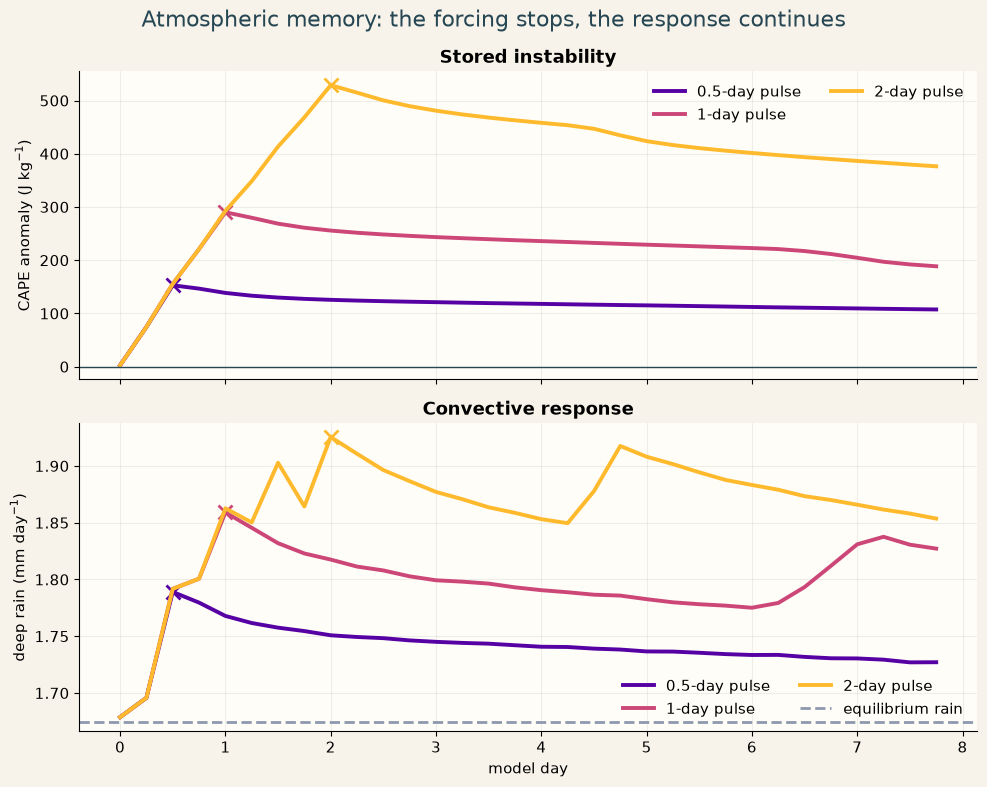

duration | omega | peak CAPE anomaly | lag after shutoff | 10% recovery
 0.5 d   | 0.05  |    152.9 J kg-1   | +0.00 d          | not by day 8
 1.0 d   | 0.05  |    290.1 J kg-1   | +0.00 d          | not by day 8
 2.0 d   | 0.05  |    528.8 J kg-1   | +0.00 d          | not by day 8
batched memory runtime: 18.7 s


In [11]:
#@title Run the atmospheric memory experiment { display-mode: "form" }
memorysettings = dict(experiment)
memorysettings['days'] = memorydays
memorysettings['diagnostic_hours'] = 6
memorygrid = make_grid(experiment['nlevels'], device=device)
memorystart = loadreference(experiment['nlevels'], batch=len(durationvalues))
memoryforcing = ascentforcing(
    memorygrid, memoryomegavalues, durationdays=durationvalues
)
grid, params, memorystate, memoryhistory, memoryelapsed = integrate(
    memorysettings, batch=len(durationvalues), state=memorystart,
    lsforcing=memoryforcing,
)
memorytime = days(memoryhistory, memorysettings['dt'])
memorycolors = plt.cm.plasma(np.linspace(0.15, 0.85, len(durationvalues)))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
memoryresults = []
for member, (omega, duration, color) in enumerate(
    zip(memoryomegavalues, durationvalues, memorycolors)
):
    cape = series(memoryhistory, 'cape', member=member)
    rain = series(memoryhistory, 'precip_conv', member=member, scale=86400)
    capeanomaly = cape - baselinecape
    label = f'{duration:g}-day pulse'
    axes[0].plot(memorytime, capeanomaly, color=color, linewidth=2.8, label=label)
    axes[1].plot(memorytime, rain, color=color, linewidth=2.8, label=label)
    axes[0].plot(duration, np.interp(duration, memorytime, capeanomaly),
                 marker='x', color=color, markersize=10, markeredgewidth=2)
    axes[1].plot(duration, np.interp(duration, memorytime, rain),
                 marker='x', color=color, markersize=10, markeredgewidth=2)

    peakindex = int(np.argmax(capeanomaly))
    peaklag = memorytime[peakindex] - duration
    peakvalue = capeanomaly[peakindex]
    after = np.where(memorytime >= duration)[0]
    recovered = after[np.abs(capeanomaly[after]) <= 0.1 * max(abs(peakvalue), 1.0)]
    recoveryday = memorytime[recovered[0]] if len(recovered) else np.nan
    memoryresults.append((duration, omega, peakvalue, peaklag, recoveryday))

axes[0].axhline(0, color=colors['storm'], linewidth=1)
axes[1].axhline(baselinerain, color=colors['cloud'], linewidth=2,
                linestyle='--', label='equilibrium rain')
axes[0].set(ylabel='CAPE anomaly (J kg$^{-1}$)', title='Stored instability')
axes[1].set(xlabel='model day', ylabel='deep rain (mm day$^{-1}$)',
            title='Convective response')
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=2)
fig.suptitle('Atmospheric memory: the forcing stops, the response continues',
             fontsize=16, color=colors['storm'])
fig.tight_layout()
plt.show()

print('duration | omega | peak CAPE anomaly | lag after shutoff | 10% recovery')
for duration, omega, peakvalue, peaklag, recoveryday in memoryresults:
    recoverytext = f'day {recoveryday:.1f}' if np.isfinite(recoveryday) else f'not by day {memorydays}'
    print(f'{duration:4.1f} d   | {omega:4.2f}  | {peakvalue:8.1f} J kg-1   | '
          f'{peaklag:+5.2f} d          | {recoverytext}')
print(f'batched memory runtime: {memoryelapsed:.1f} s')

### Mission 5 tasks

1. Mark the forcing shutoff time for each curve. Does CAPE peak before, at, or after shutoff? Explain the sign of the lag.
2. Which variable retains the clearer memory of pulse duration: CAPE or rainfall? Support the answer with two numbers.
3. The table defines recovery as returning within 10% of the largest CAPE anomaly. Decide whether that is a sensible definition and propose an alternative.
4. Explain physically why the response can persist when $omega$ has returned to zero. Your explanation should mention both stored instability and convective adjustment.
5. **Fair-fight experiment:** set `memoryomegavalues = [0.10, 0.05, 0.025]`. The products of ascent strength and duration are then equal. Run again. If integrated forcing were the only control, all three responses would match. Do they?
6. **Design your own storm:** increase `memorydays` to 10--15 and create one case that recovers quickly and one that retains a long memory. State the parameters and defend your design before running it.

For your briefing, keep the most revealing memory figure and write one sentence distinguishing an instantaneous forcing from its time-integrated impulse.

## Final challenge: can convection keep up?

You now control two competing clocks:

- **dynamical forcing:** stronger ascent destabilizes and moistens the column faster;
- **convective adjustment:** a shorter CAPE-removal timescale lets parameterized convection respond faster.

Run nine columns spanning three ascent strengths and three convective timescales. Ascent acts for one day and each case runs for two days. Predict the corner with the largest CAPE buildup and the corner with the strongest deep rainfall.

**Lock in your forecast before revealing the heatmaps.**

> Largest CAPE buildup: ______ ascent and ______ convective response.
>
> Strongest deep rain: ______ ascent and ______ convective response.

All nine columns run simultaneously. Check that the mass-flux cap remains inactive; otherwise the experiment would test the limiter rather than the intended timescale competition.


In [12]:
omegavalues = [0.02, 0.05, 0.10]
timescalevalues = [43200.0, 86400.0, 172800.0]

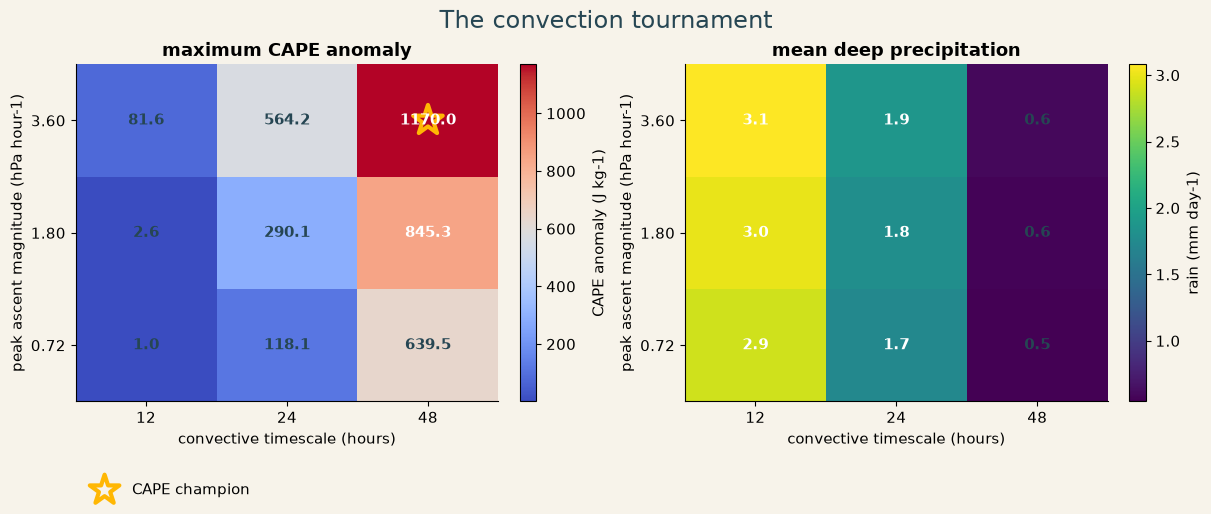

maximum cap-active fraction: 0%
largest CAPE accumulation (omega, timescale): (0.1, 172800.0)
maximum CAPE anomaly: 1170.0 J kg-1
batched challenge runtime: 4.7 s


In [13]:
#@title Run the nine-column tournament { display-mode: "form" }
cases = [(omega, timescale) for omega in omegavalues for timescale in timescalevalues]
updates = {
    'tau_cape': torch.tensor([case[1] for case in cases], device=device),
}
challengesettings = dict(experiment)
challengesettings['days'] = 2
challengegrid = make_grid(experiment['nlevels'], device=device)
challengestart = loadreference(experiment['nlevels'], batch=len(cases))
challengeforcing = ascentforcing(
    challengegrid, [case[0] for case in cases], durationdays=1.0
)
grid, params, challengestate, challengehistory, elapsed = integrate(
    challengesettings, updates=updates, batch=len(cases), state=challengestart,
    lsforcing=challengeforcing,
)
capeanomalies = []
rainrates = []
capfractions = []
referencecape = baselinecape
for member, case in enumerate(cases):
    cape = series(challengehistory, 'cape', member=member)
    capeanomalies.append(cape.max() - referencecape)
    rainrates.append(series(challengehistory, 'precip_conv', member=member, scale=86400).mean())
    capfractions.append(series(challengehistory, 'mass_flux_cap_active', member=member).mean())

capegrid = np.array(capeanomalies).reshape(len(omegavalues), len(timescalevalues))
raingrid = np.array(rainrates).reshape(len(omegavalues), len(timescalevalues))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, values, title, label, colormap in [
    (axes[0], capegrid, 'maximum CAPE anomaly', 'CAPE anomaly (J kg-1)', 'coolwarm'),
    (axes[1], raingrid, 'mean deep precipitation', 'rain (mm day-1)', 'viridis'),
]:
    image = ax.imshow(values, origin='lower', aspect='auto', cmap=colormap)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            ax.text(column, row, f'{values[row, column]:.1f}', ha='center', va='center',
                    color='white' if abs(values[row, column]) > 0.55 * np.nanmax(abs(values)) else colors['storm'],
                    fontweight='bold')
    ax.set_xticks(range(len(timescalevalues)), [f'{value / 3600:.0f}' for value in timescalevalues])
    ax.set_yticks(range(len(omegavalues)), [f'{value * 36:.2f}' for value in omegavalues])
    ax.set(xlabel='convective timescale (hours)', ylabel='peak ascent magnitude (hPa hour-1)', title=title)
    fig.colorbar(image, ax=ax, label=label)
winnerrow, winnercolumn = np.unravel_index(np.argmax(capegrid), capegrid.shape)
axes[0].scatter(winnercolumn, winnerrow, marker='*', s=500, facecolors='none',
                edgecolors=colors['sun'], linewidths=3, label='CAPE champion')
axes[0].legend(loc='upper left', bbox_to_anchor=(0, -0.20), frameon=False)
fig.suptitle('The convection tournament', fontsize=17, color=colors['storm'])
plt.show()

print(f'maximum cap-active fraction: {max(capfractions):.0%}')
winner = int(np.argmax(capeanomalies))
print('largest CAPE accumulation (omega, timescale):', cases[winner])
print(f'maximum CAPE anomaly: {capeanomalies[winner]:.1f} J kg-1')
print(f'batched challenge runtime: {elapsed:.1f} s')

## Boss level (optional): does the answer survive a new grid?

A result is more convincing when it does not depend strongly on an arbitrary grid choice. Interpolate the 20-level reference to 10, 20, and 40 levels, then give each grid one day to adjust. Compare CAPE, precipitation, and runtime.

This is a **remapping stress test**, not formal convergence: only the 20-level atmosphere was spun up on its native grid. Explain why CAPE can change when the same sounding is sampled differently, and design the separate native-grid integrations required for a real convergence claim.

In [14]:
runresolution = False #@param {type:"boolean"}

In [15]:
#@title Optional resolution experiment { display-mode: "form" }
if not runresolution:
    print('Boss level skipped. Set runresolution to True if you want to try it.')
else:
    resolutionresults = []
    for nlevels in [10, 20, 40]:
        settings = dict(experiment)
        settings['nlevels'] = nlevels
        settings['days'] = 1
        initialstate = loadreference(nlevels)
        diagnosticstate = deepcopy(initialstate)
        diagnosticgrid = make_grid(nlevels, device=device)
        diagnosticparams = makeparams(settings)
        diagnosticstate, initialdiagnostics, cache = physics_step(
            diagnosticstate, diagnosticgrid, diagnosticparams
        )
        grid, params, finalstate, history, elapsed = integrate(
            settings, state=initialstate
        )
        resolutionresults.append({
            'levels': nlevels,
            'initialcape': initialdiagnostics['cape'][0].item(),
            'cape': series(history, 'cape')[-1],
            'rain': series(history, 'precip_total', scale=86400).mean(),
            'runtime': elapsed,
        })

    for result in resolutionresults:
        print(
            f"{result['levels']:2d} levels | "
            f"CAPE {result['initialcape']:7.1f} -> {result['cape']:7.1f} J kg-1 | "
            f"mean rain {result['rain']:5.2f} mm day-1 | "
            f"runtime {result['runtime']:4.1f} s"
        )

Boss level skipped. Set runresolution to True if you want to try it.


## Your forecast briefing

Submit the completed notebook and a short forecast briefing organized around four claims:

1. **Mass and stability:** Where is the column most stable, least stable, and most massive?
2. **Process diagnosis:** Which physics tendencies maintain the reference sounding?
3. **Forecast verification:** Did your predicted signs and challenge winner match the model? Explain any miss using the equations, not hindsight.
4. **Model limits:** What important atmospheric behavior cannot occur in a single column without a dynamical core?

Include one figure that you consider the strongest evidence for your interpretation. The numerical-sensitivity boss level is optional unless assigned by your instructor.